<a href="https://colab.research.google.com/github/SilkSherstka/hse_machine_learning/blob/main/Andronova_log_reg_hw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашнее задание: линейные модели для NLP**

## **Что будем делать?**
Мы будем предсказывать, к какой категории относится новость: про хоккей или про космос.

## **Часть 1. Практическая работа (8 баллов)**

### **1. Загрузка данных**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups

# Загружаем данные о новостях
categories = ['rec.sport.hockey', 'sci.space']
newsgroups = fetch_20newsgroups(subset='all',
                               categories=categories,
                               shuffle=True,
                               random_state=42)

# Создаём таблицу с данными
data = pd.DataFrame({
    'text': newsgroups.data,
    'category': newsgroups.target  # 0 = хоккей, 1 = космос
})

print("Размер данных:", data.shape)
print("\nПервые 3 текста:")
for i in range(3):
    print(f"Текст {i+1}: {data['text'][i][:100]}...")

Размер данных: (1986, 2)

Первые 3 текста:
Текст 1: From: mccall@mksol.dseg.ti.com (fred j mccall 575-3539)
Subject: Re: Vandalizing the sky.
Article-I....
Текст 2: From: epritcha@s.psych.uiuc.edu ( Evan Pritchard)
Subject: Re: div. and conf. names
Distribution: na...
Текст 3: From: baalke@kelvin.jpl.nasa.gov (Ron Baalke)
Subject: Galileo Update - 04/29/93
Keywords: Galileo, ...


**Задание 1:**
- Сколько всего текстов в датасете?
- Выведите количество текстов в каждой категории

In [ ]:
print("Всего текстов:", len(data))
print("\nКоличество текстов в каждой категории:")
print("Хоккей (0):", sum(data['category'] == 0))
print("Космос (1):", sum(data['category'] == 1))

Всего текстов: 1986

Количество текстов в каждой категории:
Хоккей (0): 999
Космос (1): 987


### **2. Анализ данных**

In [ ]:
# Ваш код здесь
# Подсказка: используйте value_counts()
counts = data['category'].value_counts()

print("Количество текстов по категориям:")
print(counts)

# Определяем, какая категория больше
if counts[0] > counts[1]:
    print("\nБольше текстов в категории: ХОККЕЙ")
elif counts[1] > counts[0]:
    print("\nБольше текстов в категории: КОСМОС")
else:
    print("\nКоличество текстов одинаковое")

Количество текстов по категориям:
category
0    999
1    987
Name: count, dtype: int64

Больше текстов в категории: ХОККЕЙ


**Вопрос:** Какая категория больше: хоккей или космос?

### **3. Очистка текста**

In [ ]:
import re

def clean_text(text):
    # 1. Приводим к нижнему регистру
    text = text.lower()

    # 2. Удаляем всё, кроме букв и пробелов
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # 3. Убираем лишние пробелы
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Применяем функцию
data['clean_text'] = data['text'].apply(clean_text)

# Проверяем
print("До очистки:", data['text'][0][:100])
# Строка после чистки получается длиннее, так как были удалены лишние символы
print("После очистки:", data['clean_text'][0][:100])

До очистки: From: mccall@mksol.dseg.ti.com (fred j mccall 575-3539)
Subject: Re: Vandalizing the sky.
Article-I.
После очистки: from mccall mksol dseg ti com fred j mccall subject re vandalizing the sky article i d mksol apr org


### **4. Создание признаков (векторизация)**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# 1. Создаём CountVectorizer с английскими стоп-словами
vectorizer = CountVectorizer(stop_words='english')

# 2. Преобразуем очищенные тексты в матрицу признаков
X = vectorizer.fit_transform(data['clean_text'])

# 3. Выводим количество уникальных слов
print("Количество уникальных слов:", len(vectorizer.get_feature_names_out()))

Количество уникальных слов: 24480


**Вопрос:** Сколько уникальных слов нашёл CountVectorizer?

### **5. Разделение данных**

In [ ]:
from sklearn.model_selection import train_test_split

# Цель: предсказать категорию (0 или 1)
X = X # что сюда подставить? (признаки) -> матрица признаков из CountVectorizer
y = data['category'] # что сюда подставить? (целевая переменная) -> категория: 0 или 1

# Ваш код здесь
# Разделите данные на 80% обучение, 20% тест
# Используйте random_state=42

# Делим данные: 80% обучение, 20% тест
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (1588, 24480)
Размер тестовой выборки: (398, 24480)


### **6. Обучение модели**

In [ ]:
from sklearn.linear_model import LogisticRegression

# Ваш код здесь
# 1. Создайте модель логистической регрессии
# 2. Обучите её на обучающих данных
# 3. Сделайте предсказания для тестовых данных

# увеличиваем число итераций, чтобы алгоритм точно сходился для большого числа признаков
model = LogisticRegression(max_iter=1000, random_state=42)
# обучение модели
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Первые 10 предсказаний:", y_pred[:10])

Первые 10 предсказаний: [0 0 1 1 0 0 0 0 0 1]


### **7. Оценка модели**

In [ ]:
from sklearn.metrics import accuracy_score

# Ваш код здесь
# 1. Вычислите accuracy (точность) модели
# 2. Выведите результат в процентах

accuracy = accuracy_score(y_test, y_pred)
print(f"Точность модели: {accuracy * 100:.2f}%")

# accuracy - это отношение правильно предсказанных текстов на количество всех текстов в тестовой выборке
# модель хорошо различает тексты двух категорий, потому что слова и термины для хоккея и космоса сильно отличаются

Точность модели: 99.25%


**Вопрос:** Какая точность у вашей модели? Что это значит?

### **8. Анализ ошибок**

Матрица ошибок:
[[201   1]
 [  2 194]]


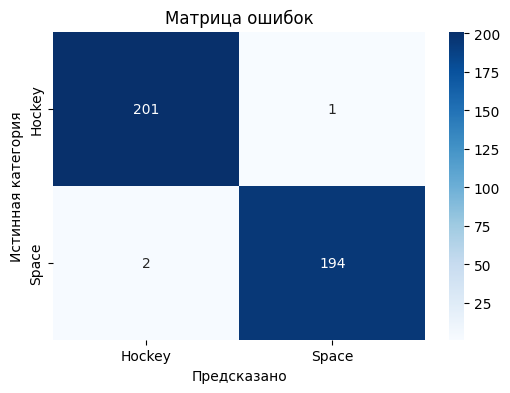

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Ваш код здесь
# 1. Создайте матрицу ошибок
# 2. Выведите её

cm = confusion_matrix(y_test, y_pred)

print("Матрица ошибок:")
print(cm)

# БОНУС: визуализируйте матрицу ошибок
plt.figure(figsize=(6, 4))
# Ваш код для визуализации здесь
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Hockey', 'Space'],
            yticklabels=['Hockey', 'Space'])
plt.xlabel('Предсказано')
plt.ylabel('Истинная категория')
plt.title('Матрица ошибок')
plt.show()

# строки — истинная категория, cтолбцы — предсказанная категория
# 201 - тексты хоккея, правильно классифицированы как хоккей
# 194 - тексты космоса, правильно классифицированы как космос
# 1 - текст хоккея ошибочно классифицирован как космос
# 2 - тексты космоса ошибочно классифицированы как хоккей

**Вопрос:** Сколько текстов про космос модель приняла за хоккей?

2 текста